## <center>CITS5508 Assignment 1</center>

Author: Seng Qi Ming (25303739)

 - [Softmax Regression](#part-1-softmax-regression)
 - [Support Vector Machine Regression](#part-2-support-vector-machine-regression)


### Importing necessary libraries

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error


## Part 1: Softmax Regression

In this task, we implement a Softmax Regression from scratch using gradient descent optimisation and apply it to the MNIST dataset. <br>
The objective is to classify each handwritten numbers from the dataset into 10 classes (digits 0 to 9)

Softmax Regression is a generalisation of logistic regression for multiclass classification problems. It estimates the probability of input vector  $\mathbf{x}$ belonging to class $k$ as,

$$\hat{p}_{k} = \frac{\exp(s_{k}(\mathbf{x}))}{\sum^{K}_{j=1}\exp(s_{j}(\mathbf{x}))},$$

where $K$ is the total number of classes and $s_{k}(\mathbf{x}) = (\theta^{(k)})^{T}\mathbf{x}$.

The cost function used in softmax Regression is the cross-entropy loss (also known as log loss) which measures how well the predicted probabilities match the true labels is given by: 
$$J(\theta) = -\frac{1}{m}\sum^{m}_{i=1}\sum^{K}_{k=1}y_{k}^{(i)}\log(\hat{p}_{k}^{(i)})$$

where $y_{k}^{i}$ is the target probability that the $i^{th}$ instance belongs to class $k$ (1 if sample $i$ belongs to class $k$, else 0). Then $\partial{J}/\partial{\mathbf{\theta}^{(k)}}$ is given by,
$$\frac{\partial{J}}{\partial{\mathbf{\theta^{(k)}}}} = \frac{1}{m}\sum^{m}_{i=1}(\hat{p}^{(i)}_{k} - y^{(i)}_{k})\mathbf{x}^{(i)}.$$


### Step 1: Load the dataset
We will first load the dataset using the `sklearn.datasets.fetch_openml`

In [126]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

### Step 2: Inspect the data

Source - [openML mnist_784](https://www.openml.org/search?type=data&sort=runs&id=554&status=active)

From the link above, the dataset contain 784 features (as each images contain 28x28 pixels) with 70,000 examples (images). 

This can be verified using the shape and type of x and y, with some examples displayed

In [127]:
print(f'X shape: {X.shape}, X dtype: {X.dtype}')
print(f'Y shape: {y.shape}, Y dtype: {y.dtype}')
print('\nShowing the top 10 rows of X and Y')
print(f'X[:10]: \n{X[:10]}\n')
print(f'y[:10]: \n{y[:10]}\n')
print(f'Labels from Y: {sorted(list(set(y)))}')

X shape: (70000, 784), X dtype: int64
Y shape: (70000,), Y dtype: object

Showing the top 10 rows of X and Y
X[:10]: 
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

y[:10]: 
['5' '0' '4' '1' '9' '2' '1' '3' '1' '4']

Labels from Y: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


As we can see for `X[0]` its show a 5 whereas the label show a 5 as well

* the intuition here is that in X (the features) per row its contains 28*28 pixels where is pixel (0 - 255), we can map it together to create an image

In [128]:
print(f'Min value in X[0]: {min(X[0])} and Max value in X[0]: {max(X[0])}')

Min value in X[0]: 0 and Max value in X[0]: 255


Heres a visualisation of the first 10 labels

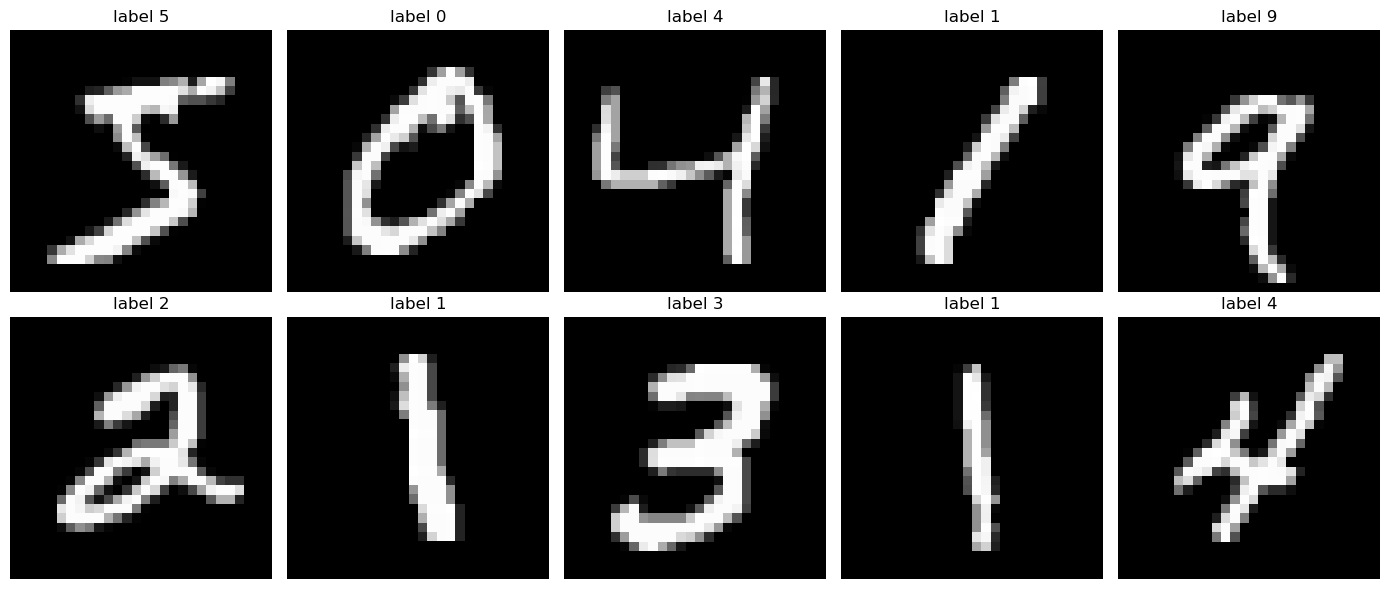

In [129]:
fig, axes = plt.subplots(2,5, figsize=(14, 6))
for index, axes in enumerate(axes.flatten()):
    img = X[index].reshape(28, 28)  #img -> display a 2D (or 3D) array as an image
    axes.imshow(img,  cmap='gray')
    axes.set_title(f'label {y[index]}')
    axes.axis('off')
plt.tight_layout()
plt.show()

### Step 3: Splitting of dataset

For training of our model, we will split the dataset into 70% for training, 15% for validation and 15% for testing.
Then we will inspect and decision if stratification is required.
*stratification mean splitting data while preserving the original distribution of classes.

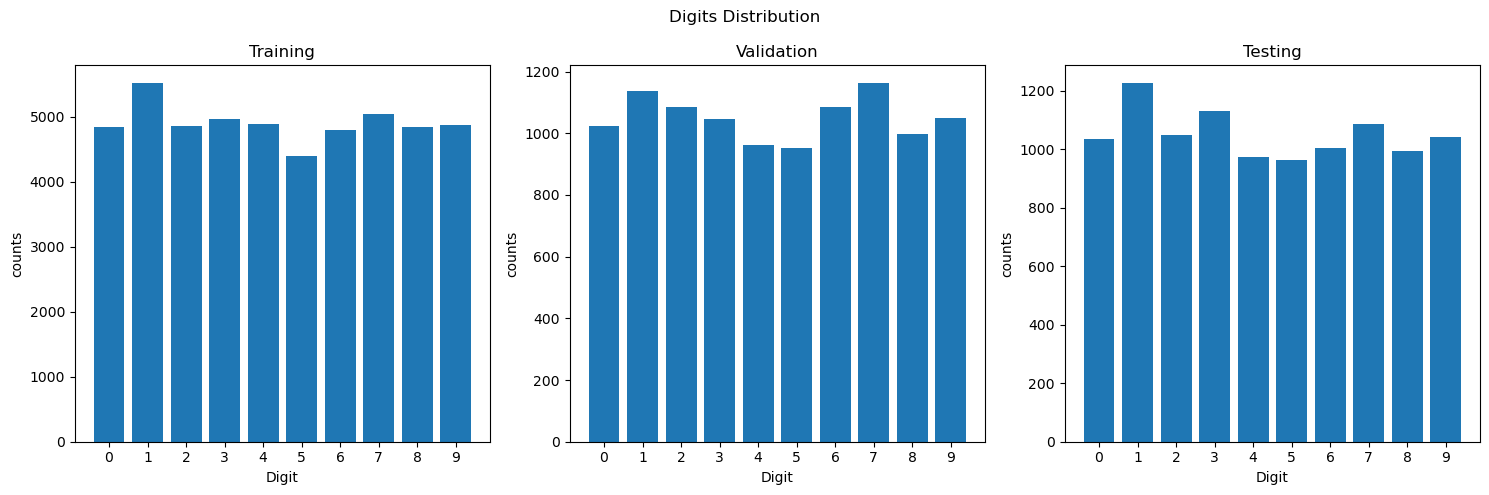

In [130]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

def displayplot(y_train, y_valid, y_test):
    data = [('Training', y_train), ('Validation', y_valid), ('Testing', y_test)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Digits Distribution')

    for index, (name, data) in enumerate(data):
        counts = pd.Series(data).value_counts().sort_index()
        axes[index].bar(counts.index, counts.values)
        axes[index].set_title(name)
        axes[index].set_xlabel("Digit")
        axes[index].set_ylabel('counts')

    plt.tight_layout()
    plt.show()

displayplot(y_train, y_valid, y_test)

The digit classes are fairly balanced, but having stratification done is still preferable because its preserves the same class proportions in the training/ validation and test set as in the original dataset. This makes model evaluation more reliable and reduces the risk of accidental class imbalance.

Straification will be done by doing the split of data again with `stratify=y` in the parameters

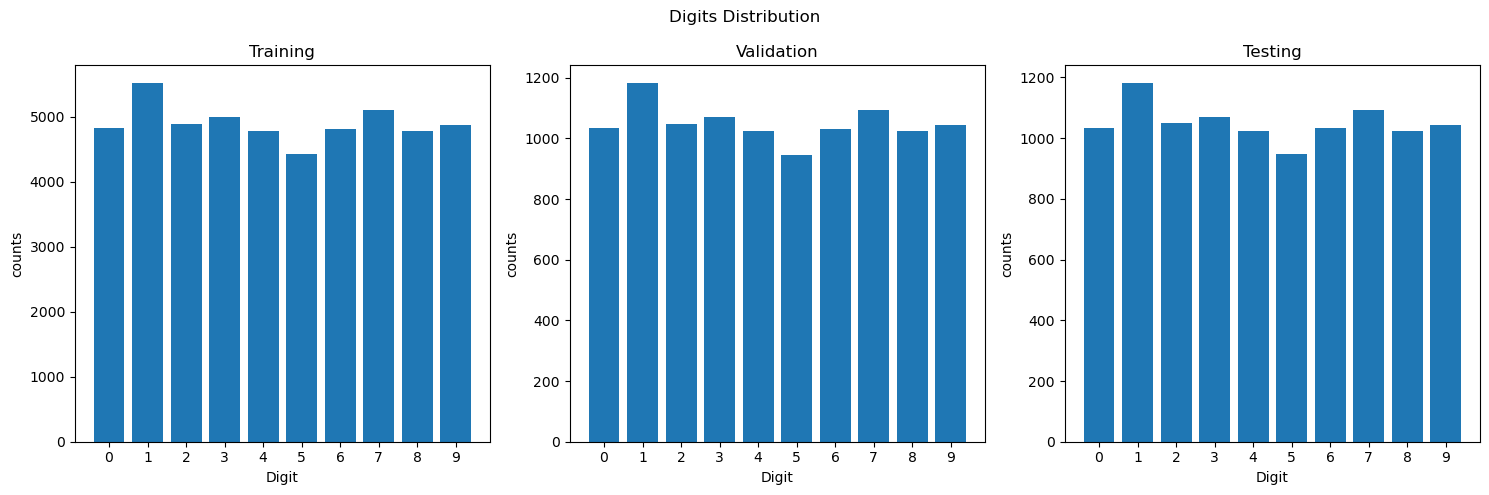

X_train shape: (49000, 784)
X_valid shape: (10500, 784)
X_test shape: (10500, 784)


In [131]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

displayplot(y_train, y_valid, y_test)

print(f'X_train shape: {X_train.shape}\nX_valid shape: {X_valid.shape}\nX_test shape: {X_test.shape}')

### Step 4: Implement Softmax Regression From Scratch

In [132]:
class softmaxGDRegressor:
    def __init__(self, learning_rate = 0.1, n_epochs=1000, patience=10):
        """
            Learning Rate: determine the rate of convergence for our weights while using GD
            n_epochs: specifics the number of iterations 
            l2: regularisation parameters
        """
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.theta = None
        self.losses = {'train_loss': [], 'val_loss': []}
        self.patience = patience

    def softmax(self, x):
        """Softmax Function"""
        return np.exp(x)/np.sum(np.exp(x), axis=1, keepdims=True)
    
    def loss(self, y_true, y_probs):
        """Loss Function"""
        m = y_true.shape[0]
        return (-1/m) * np.sum(y_true * np.log(y_probs))
                        
    def gradient(self, X, y_true, y_probs):
        """Gradient Function"""
        m = X.shape[0]
        return (1/m) * X.T @ (y_probs - y_true)
    
    def predict(self, X):
        X_bias = np.insert(X, 0, 1, axis=1)
        p_hat = self.softmax(X_bias @ self.theta)
        return np.argmax(p_hat, axis = 1)

    def one_hot_encoder(self, y, num_classes):
        y = y.astype(int)
        return np.eye(num_classes)[y]
    
    def train(self, X_train, y_train, X_val, y_val):
        n_samples, n_features = X_train.shape
        n_classes = len(np.unique(y_train.astype(int)))

        X_train_bias = np.insert(X_train, 0, 1, axis=1)
        X_val_bias = np.insert(X_val, 0, 1, axis=1)

        y_train_ohe = self.one_hot_encoder(y_train, n_classes)
        y_valid_ohe = self.one_hot_encoder(y_val, n_classes)

        self.theta = np.zeros((n_features + 1, n_classes))

        # Variables for early stopping
        best_loss = float('inf')
        epoch_no_improvement = 0
        best_theta = None

        for epoch in range(1, self.n_epochs + 1):
            train_probs = self.softmax(X_train_bias @ self.theta)
            val_probs = self.softmax(X_val_bias @ self.theta)

            train_loss = self.loss(y_train_ohe, train_probs)
            val_loss = self.loss(y_valid_ohe, val_probs)

            grad = self.gradient(X_train_bias, y_train_ohe, train_probs)
            self.theta -= self.learning_rate * grad
            self.losses['train_loss'].append(train_loss)
            self.losses['val_loss'].append(val_loss)

            if val_loss < best_loss:
                best_loss = val_loss
                best_theta = self.theta.copy()
                epoch_no_improvement = 0
            else:
                epoch_no_improvement +=1
            
            if epoch_no_improvement >= self.patience:
                break

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")
        
        self.theta = best_theta
        

In [ ]:
range_val = np.max(X_train) - np.min(X_train)
X_train_scaled = X_train / range_val
X_val_scaled = X_valid / range_val
X_test_scaled = X_test / range_val

sgd = softmaxGDRegressor() 
sgd.train(X_train=X_train_scaled, y_train=y_train, X_val=X_val_scaled, y_val=y_valid)

Epoch 100: Train Loss 0.6058 | Val Loss 0.6160
Epoch 200: Train Loss 0.4851 | Val Loss 0.4967
Epoch 300: Train Loss 0.4357 | Val Loss 0.4485
Epoch 400: Train Loss 0.4074 | Val Loss 0.4210
Epoch 500: Train Loss 0.3884 | Val Loss 0.4029
Epoch 600: Train Loss 0.3745 | Val Loss 0.3898
Epoch 700: Train Loss 0.3637 | Val Loss 0.3797


In [ ]:
y_pred = sgd.predict(X_test_scaled)
print(classification_report(y_test.astype(int), y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1035
           1       0.84      0.96      0.89      1181
           2       0.87      0.79      0.83      1049
           3       0.77      0.83      0.80      1071
           4       0.86      0.86      0.86      1024
           5       0.87      0.64      0.74       947
           6       0.88      0.92      0.90      1032
           7       0.89      0.88      0.88      1094
           8       0.78      0.77      0.78      1024
           9       0.80      0.80      0.80      1043

    accuracy                           0.84     10500
   macro avg       0.84      0.84      0.84     10500
weighted avg       0.84      0.84      0.84     10500



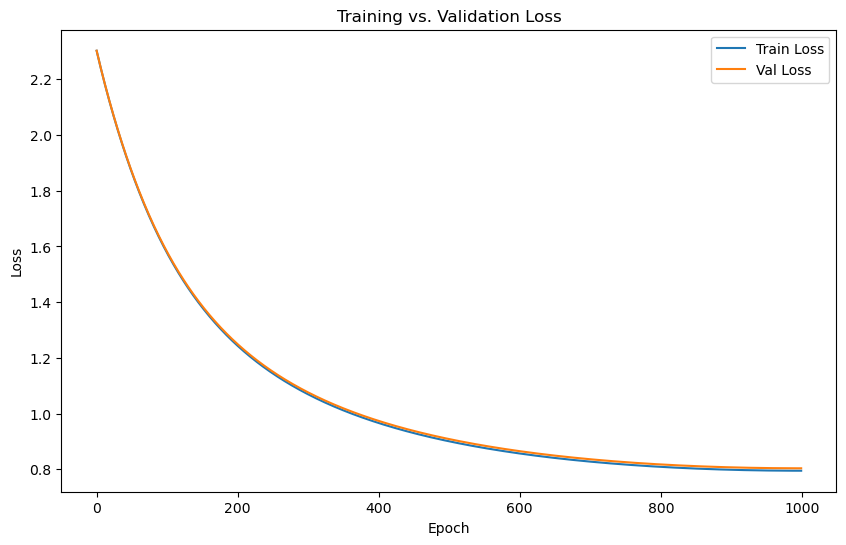

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,6))

n_epoch = range(len(sgd.losses['train_loss']))
plt.plot(n_epoch, sgd.losses['train_loss'], label='Train Loss')
plt.plot(n_epoch, sgd.losses['val_loss'], label='Val Loss')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.tight_layout()
plt.show()

In [ ]:
log_reg = LogisticRegression(penalty=None, max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

KeyboardInterrupt: 

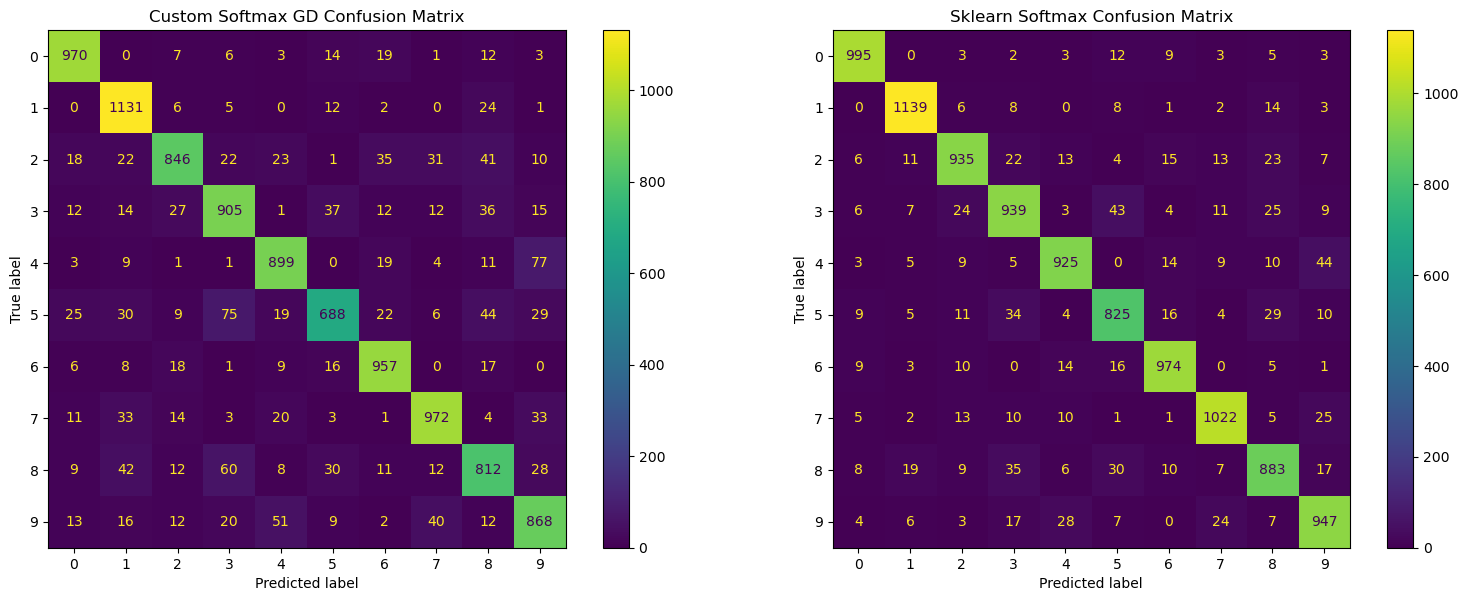

In [ ]:
y_pred_custom = sgd.predict(X_test_scaled)
y_pred_sklearn = log_reg.predict(X_test_scaled)

y_test_int = y_test.astype(int)
y_pred_sklearn = y_pred_sklearn.astype(int)
y_pred_custom = y_pred_custom.astype(int)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred_custom, ax=axes[0])
axes[0].set_title("Custom Softmax GD Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred_sklearn, ax=axes[1])
axes[1].set_title("Sklearn Softmax Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Get classifcation report for both models
report_custom = classification_report(y_test_int, y_pred_custom)
report_sklearn = classification_report(y_test_int, y_pred_sklearn)

# Display side-by-side
lines_custom = report_custom.split('\n')
lines_sklearn = report_sklearn.split('\n')

header_custom = "Custom Softmax Regression GD Model"
header_sk = "Sklearn Logistic Regression Model"
print(f"{header_custom:<55} | {header_sk}")
print("-" * 120)

for c, s in zip(lines_custom, lines_sklearn):
    print(f"{c.ljust(55)} | {s}")

Custom Softmax Regression GD Model                      | Sklearn Logistic Regression Model
-------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support   |               precision    recall  f1-score   support
                                                        | 
           0       0.91      0.94      0.92      1035   |            0       0.95      0.96      0.96      1035
           1       0.87      0.96      0.91      1181   |            1       0.95      0.96      0.96      1181
           2       0.89      0.81      0.85      1049   |            2       0.91      0.89      0.90      1049
           3       0.82      0.85      0.83      1071   |            3       0.88      0.88      0.88      1071
           4       0.87      0.88      0.87      1024   |            4       0.92      0.90      0.91      1024
           5       0.85      0.73      0.78       947   |    

## Part 2: Support Vector Machine Regression

### Step 1: Creating the Toy function for generating of dataset


$$y = \sum^{n}_{k=0}a_{k}x^{k} + \epsilon
$$

In [ ]:
def gen_toy_dataset(degree, n_samples):
    np.random.seed(42)
    x = np.random.uniform(-3,3, n_samples)
    a_k = np.random.uniform(0, 1, degree + 1)
    y = np.array([0.0] * n_samples)

    for k in range(degree + 1):
        y += a_k[k] * (x ** k)
    
    epsilon = np.random.normal(0, 1, n_samples)
    y = y + epsilon
    return x, y

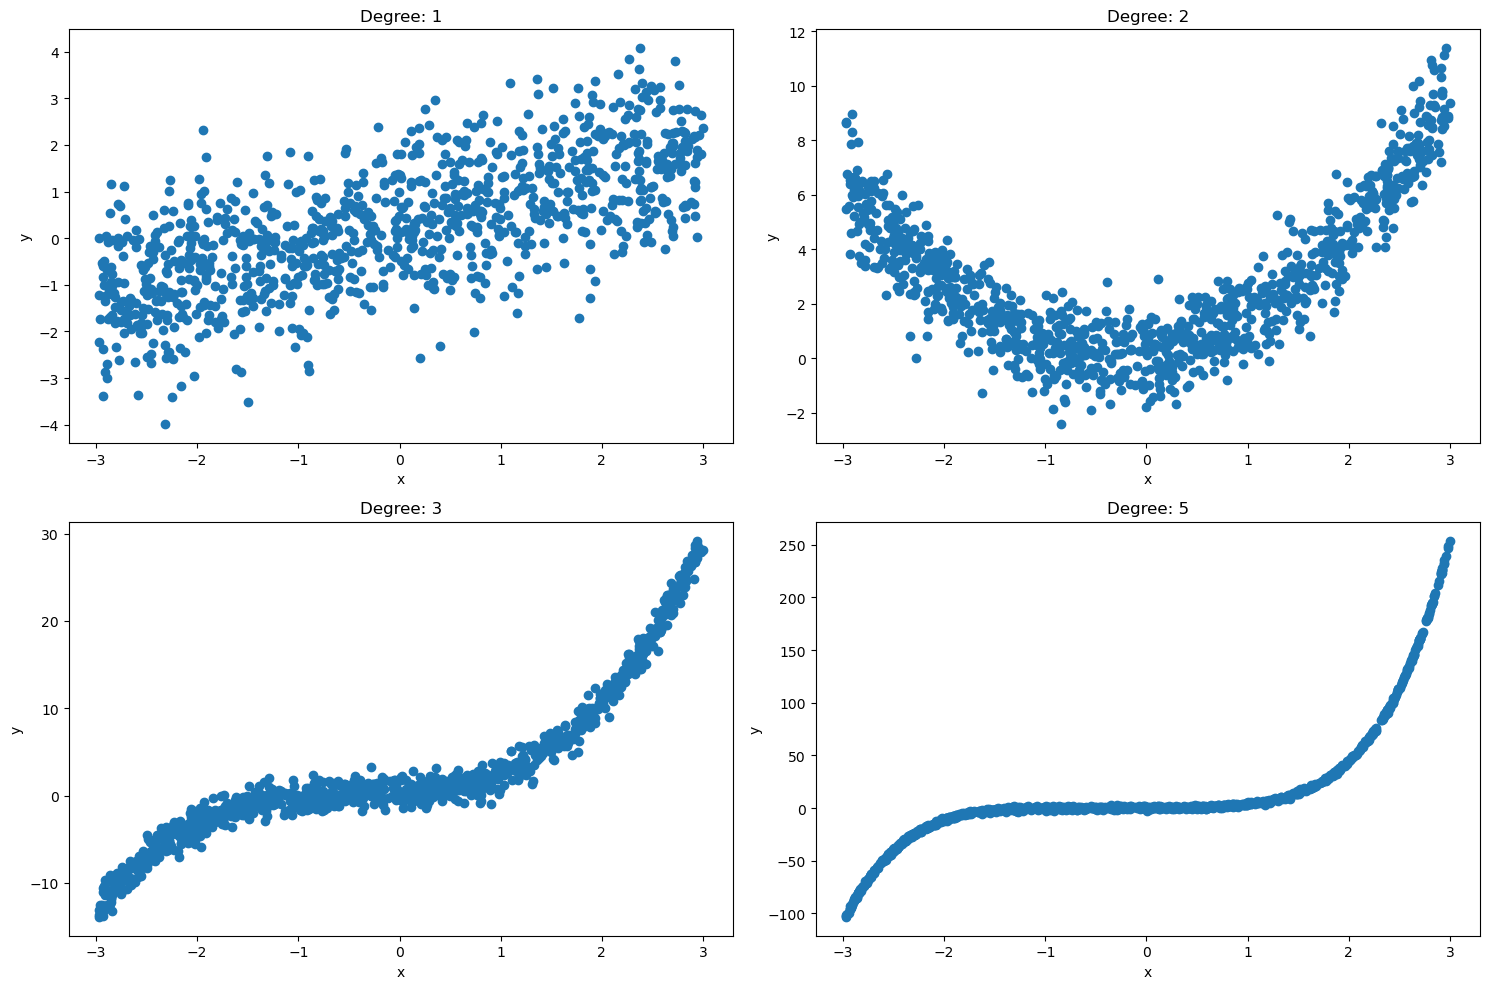

In [ ]:
def plot_dataset(degrees, samples=1000):
    plt.figure(figsize=(15,10))
    for index, degree in enumerate(degrees):
        x, y = gen_toy_dataset(degree=degree, n_samples=samples)
        plt.subplot(2, 2, index + 1)
        plt.scatter(x, y)
        plt.title(f'Degree: {degree}')
        plt.xlabel('x')
        plt.ylabel('y')
    
    plt.tight_layout()
    plt.show()

plot_dataset([1,2,3,5], 1000)

### Step 2: Generate three toy datasets using your function: a linear, a quadratic, and cubic dataset. 
Use n samples = 1000. Make sure you have a training and test set for each dataset

In [ ]:
n_samples = 1000

# Generating dataset using toy function above
x_linear, y_linear = gen_toy_dataset(degree=1, n_samples=n_samples)
x_quad, y_quad = gen_toy_dataset(degree=2, n_samples=n_samples)
x_cubic, y_cubic = gen_toy_dataset(degree=3, n_samples=n_samples)

# Splitting of data
x_linear_train, x_linear_test, y_linear_train, y_linear_test = train_test_split(x_linear, y_linear, test_size=0.20, random_state=42)
x_quad_train, x_quad_test, y_quad_train, y_quad_test = train_test_split(x_quad, y_quad, test_size=0.20, random_state=42)
x_cubic_train, x_cubic_test, y_cubic_train, y_cubic_test = train_test_split(x_cubic, y_cubic, test_size=0.20, random_state=42)

print(f'For linear -> x_train: {x_linear_train.shape}, x_test: {x_linear_test.shape}')
print(f'For quad -> x_train: {x_quad_train.shape}, x_test: {x_quad_test.shape}')
print(f'For cubic -> x_train: {x_cubic_train.shape}, x_test: {x_cubic_test.shape}')

For linear -> x_train: (800,), x_test: (200,)
For quad -> x_train: (800,), x_test: (200,)
For cubic -> x_train: (800,), x_test: (200,)


### Step 3:
Experiment with fitting a sklearn.svm.SVR model to each of the three datasets using kernel=’linear’,
kernel=’poly’ and kernel=’rbf’.

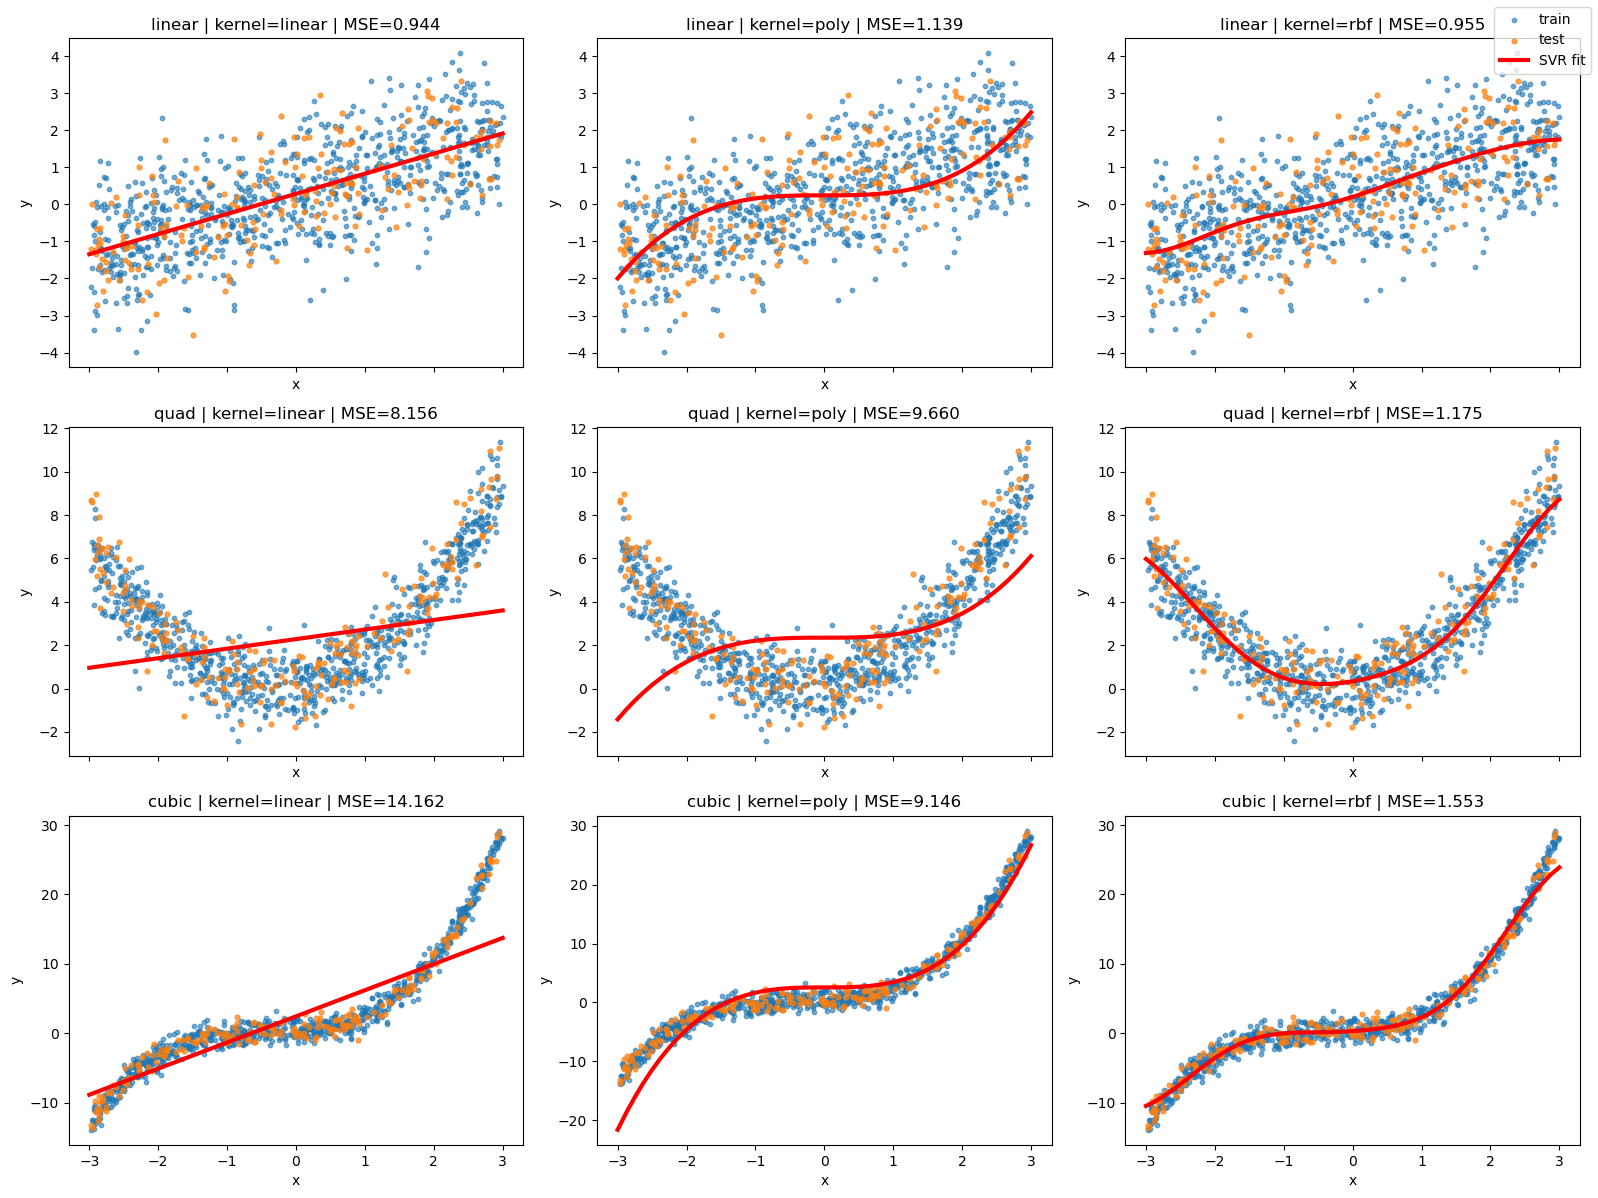

In [ ]:
kernels = ['linear', 'poly', 'rbf']
datasets = {
    'linear': (x_linear_train, y_linear_train, x_linear_test, y_linear_test),
    'quad': (x_quad_train, y_quad_train, x_quad_test, y_quad_test),
    'cubic': (x_cubic_train, y_cubic_train, x_cubic_test, y_cubic_test)
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)

for row, (name, dataset) in enumerate(datasets.items()):
    x_train, y_train, x_test, y_test = dataset
    x_train  = x_train.reshape(-1, 1)
    x_test  = x_test.reshape(-1, 1)
    
    for col, param in enumerate(kernels):
        svr = SVR(kernel=param)
        svr.fit(x_train, y_train)

        y_test_pred = svr.predict(x_test)
        mse = mean_squared_error(y_test, y_test_pred)

        x_grid = np.linspace(-3, 3).reshape(-1, 1)
        y_grid_pred = svr.predict(x_grid)
        
        ax = axes[row, col]
        ax.scatter(x_train, y_train, s=10, alpha=0.6, label="train")
        ax.scatter(x_test, y_test, s=12, alpha=0.7, label="test")
        ax.plot(x_grid, y_grid_pred, color="red", linewidth=3, label="SVR fit")
        ax.set_title(f"{name} | kernel={param} | MSE={mse:.3f}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

### Step 4:
perform grid-search with k-fold cross-validation (k = 5) on at least three hyperparameters (including
kernel) with two different values each (23 = 8 total combinations) for your cubic dataset

In [ ]:
x_cubic_train  = x_cubic_train.reshape(-1, 1)
x_cubic_test  = x_cubic_test.reshape(-1, 1)
grid_search = GridSearchCV(
    SVR(),
    {'kernel':kernels, 'C':[1, 5], 'epsilon':[0.1, 0.5]},
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    refit=True
)

grid_search.fit(x_cubic_train, y_cubic_train)
print(pd.DataFrame(grid_search.cv_results_)[['param_kernel','param_epsilon','param_C','mean_test_score','std_test_score','rank_test_score']].sort_values('rank_test_score'))
print(f'best params: {grid_search.best_params_}')
print(f'Best score: {-grid_search.best_score_}')

   param_kernel  param_epsilon  param_C  mean_test_score  std_test_score  \
11          rbf            0.5        5        -1.155289        0.129582   
8           rbf            0.1        5        -1.155518        0.126809   
2           rbf            0.1        1        -2.012277        0.065257   
5           rbf            0.5        1        -2.015572        0.095945   
4          poly            0.5        1        -7.112936        0.565904   
10         poly            0.5        5        -7.194618        0.582425   
1          poly            0.1        1        -7.216971        0.565095   
7          poly            0.1        5        -7.269396        0.578008   
9        linear            0.5        5       -16.797748        1.686455   
3        linear            0.5        1       -16.850029        1.743662   
6        linear            0.1        5       -16.881534        1.811024   
0        linear            0.1        1       -16.941604        1.832446   

    rank_te

### Step 5: Evaluate Best Model

We will take the model with the best parameter from step 4 for evaluation.

Train MSE: 1.15529
Train RMSE: 1.07484
Test MSE: 1.0105639893847929
Test RMSE: 1.0052681181579335


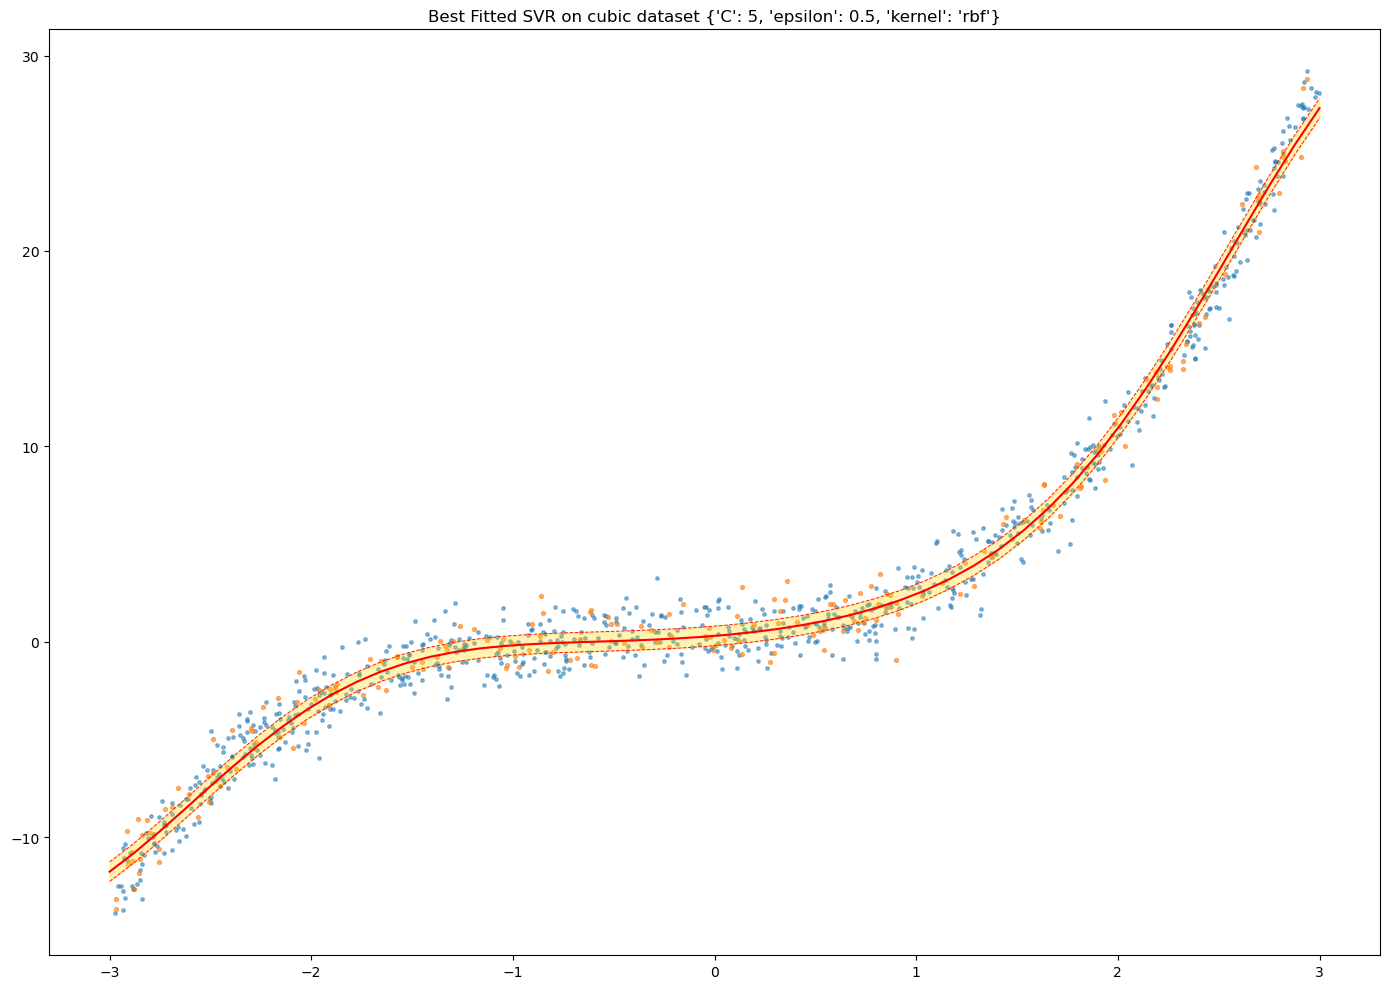

In [ ]:
best_model = grid_search.best_estimator_

# Calculating the evaluation metrics

y_cubic_pred = best_model.predict(x_cubic_test)
mse_test = mean_squared_error(y_true=y_cubic_test, y_pred=y_cubic_pred)

print(f'Train MSE: {-grid_search.best_score_:.5f}')
print(f'Train RMSE: {np.sqrt(-grid_search.best_score_):.5f}')
print(f'Test MSE: {mse_test}')
print(f'Test RMSE: {np.sqrt(mse_test)}')

# Plot the result
x_grid = np.linspace(-3, 3).reshape(-1, 1)
y_grid_pred = best_model.predict(x_grid)
epsilon = grid_search.best_params_['epsilon']

plt.figure(figsize=(14,10))
plt.title(f'Best Fitted SVR on cubic dataset {grid_search.best_params_}')
plt.scatter(x_cubic_train, y_cubic_train, s=6, alpha=0.5, label='train')
plt.scatter(x_cubic_test, y_cubic_test, s=8, alpha=0.6, label='Test')
plt.plot(x_grid, y_grid_pred, color="red", linewidth=1.5, label="SVR Best fit")
plt.fill_between(x_grid.ravel(),  y_grid_pred - epsilon, y_grid_pred + epsilon, color='gold', alpha=0.30)

plt.plot(x_grid, y_grid_pred - epsilon, 'r--', linewidth=0.7, alpha=0.9)
plt.plot(x_grid, y_grid_pred + epsilon, 'r--', linewidth=0.7, alpha=0.9)

plt.tight_layout()
plt.show()